# Grafo y predicciones

En este notebook, junto a `VRP_ortools.ipynb` y `VRP_algoritmo_genetico.ipynb`, vamos a crear la fase de optimización de rutas.

Aquí contruimos un grafo real de las calles de Chicago, con los pesos (el tiempo de viaje) de cada tramo predecido por nuestros modelos para 4 escenarios distintos y guardamos las matrices de tiempo resultantes.

Al final de este notebook,después de haber ejecutado `VRP_ortools.ipynb` y `VRP_algoritmo_genetico.ipynb`, donde resolveremos el problema de rutas de reparto con varios vehículos, cargamos los resultados y hacemos la comparativa final.

Los 4 escenarios que calcularemos son los siquientes:

| Escenario | Momento | Modelo |
|---|---|---|
| `historico_lgbm` | última hora del histórico | LightGBM (principal + respaldo) |
| `vivo_lgbm` | ahora mismo | LightGBM (principal + respaldo) |
| `historico_gcn` | última hora del histórico | GCN + respaldo |
| `vivo_gcn` | ahora mismo | GCN + respaldo |

Vamos a usar el mismo depósito y entregas en los 4 escenarios para una justa comparación entre escenarios.

## 0. Importación de paquetes

In [ ]:
!pip install osmnx --quiet
!pip install ortools --quiet
!pip install torch_geometric --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 23.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.6 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 13.9 MB/s eta 0:00:00


In [ ]:
import osmnx as ox
import networkx as nx
import pandas as pd
import numpy as np
import duckdb
import lightgbm as lgb
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
import requests
import random
import math
import pickle
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

data_clean = "/content/drive/MyDrive/TFM/data_clean"

Mounted at /content/drive


## 1. Grafo de calles

El primer paso será descargar las calles de Chicago de OpenStreetMap (por las que se puede circular en coche).

In [ ]:
# descargamos el grafo

G = ox.graph_from_place("Chicago, Illinois, USA", network_type="drive")

print(f"Nodos: {len(G.nodes)}")
print(f"Aristas: {len(G.edges)}")

Nodos: 29832
Aristas: 77821


El grafo de Chicagode OSM tiene 29.832 nodos y 77.821 arsitas en total.

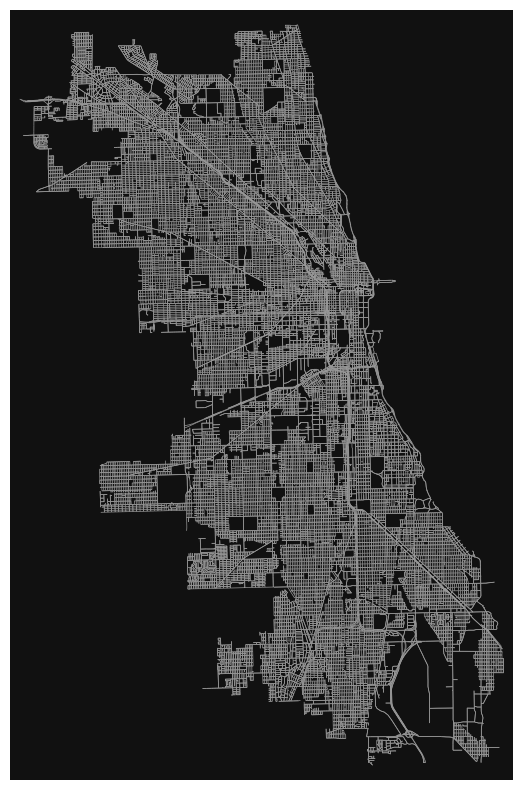

(<Figure size 1000x1000 with 1 Axes>, <Axes: >)

In [ ]:
# visualizamos el grafo
ox.plot_graph(G, node_size=0, edge_linewidth=0.5, figsize=(10, 10))

In [ ]:
# vemos que informacion tiene cada arista

u, v, datos = list(G.edges(data=True))[0]
print(datos)

edges_gdf = ox.graph_to_gdfs(G, nodes=False)

print(f"Total aristas: {len(edges_gdf)}")
print(f"Con 'name': {edges_gdf['name'].notna().sum()} ({edges_gdf['name'].notna().mean()*100:.1f}%)")
print(f"Con 'maxspeed': {edges_gdf['maxspeed'].notna().sum() if 'maxspeed' in edges_gdf else 0} ({(edges_gdf['maxspeed'].notna().mean()*100 if 'maxspeed' in edges_gdf else 0):.1f}%)")

print("\nDistribución de tipos de vía (highway):")
print(edges_gdf["highway"].value_counts().head(15))

{'osmid': 24536463, 'highway': 'motorway_link', 'oneway': True, 'reversed': False, 'length': np.float64(323.56242380560957), 'geometry': <LINESTRING (-87.818 41.983, -87.818 41.984, -87.818 41.984, -87.819 41.984,...>}
Total aristas: 77821
Con 'name': 76069 (97.7%)
Con 'maxspeed': 6411 (8.2%)

Distribución de tipos de vía (highway):
highway
residential       48381
secondary         14341
tertiary          10169
primary            2024
unclassified        931
motorway_link       657
motorway            521
trunk               170
busway              166
secondary_link      156
emergency_bay        78
trunk_link           61
tertiary_link        38
living_street        35
primary_link         33
Name: count, dtype: int64


Vemos que solo el 8.2% de aristas tienen `maxspeed` en OSM, así que no podemos depender de eso para estimar la velocidad.

Además, en nuestros datos solo tenemos 1.046 segmentos de las 77.821 aristas en total que tiene el grafo. Por lo tanto, vamos a crear un segundo modelo en el archivo `modelo2.ipynb` que generalice a calles no vistas para predecir la velocidad de los demás segmentos.

## 2. Cargamos los modelos

### 2.1. LightGBM (principal y de respaldo)

A continuación, cargamos los dos modelos de LightGBM y el emparejamiento entre nuestros segmentos y las aristas de OSM calculado en `modelo2.ipynb`.

In [ ]:
# cargamos modelos y emparejamiento

modelo_principal = lgb.Booster(model_file=f"{data_clean}/modelo_trafico.txt")
modelo_respaldo = lgb.Booster(model_file=f"{data_clean}/modelo2_trafico.txt")

segmentos_monitorizados = pd.read_parquet(f"{data_clean}/segmentos_monitorizados.parquet")
print(f"Aristas de OSM cubiertas por algún segmento: {len(segmentos_monitorizados)}")

Aristas de OSM cubiertas por algún segmento: 16443


Tenemos 16.443 aristas de OSM cubiertas por algún segmento.

### 2.2. GCN

Cargamos el checkpoint que guardamos en `deep_learning.ipynb`: los pesos del modelo, la normalización, el mapeo de nodos y el grafo de adyacencia entre nuestros segmentos.

In [ ]:
# cargamos datos
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint_gcn = torch.load(f"{data_clean}/modelo_gcn_final.pt", map_location=device, weights_only=False)
node_to_idx = checkpoint_gcn["node_to_idx"]
feature_mean = checkpoint_gcn["feature_mean"]
feature_std = checkpoint_gcn["feature_std"]
n_features_gcn = checkpoint_gcn["n_features"]
idx_to_node = {v: k for k, v in node_to_idx.items()}

npz_gcn = np.load(f"{data_clean}/gcn_snapshots.npz")
edge_index_gcn = torch.tensor(npz_gcn["edge_index"], dtype=torch.long).to(device)

class TrafficGCN(nn.Module):
    def __init__(self, n_features, hidden_dim=64):
        super().__init__()
        self.conv1 = GCNConv(n_features, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)
        self.salida = nn.Linear(hidden_dim, 1)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))
        return self.salida(x).squeeze(-1)

modelo_gcn = TrafficGCN(n_features=n_features_gcn).to(device)
modelo_gcn.load_state_dict(checkpoint_gcn["model_state"])
modelo_gcn.eval()

TrafficGCN(
  (conv1): GCNConv(16, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (salida): Linear(in_features=64, out_features=1, bias=True)
)

### 2.3. Baseline y función para construir un snapshot de la GCN

Usamos el baseline (velocidad típica por segmento, día de la semana y hora) para imputar huecos, igual que en `deep_learning.ipynb`. La función `construir_snapshot` es la misma que usamos allí para entrenar.

In [ ]:
con = duckdb.connect()

baseline = con.sql(f"""
    SELECT
        segment_id,
        EXTRACT(DOW FROM time_hour) AS dow,
        EXTRACT(HOUR FROM time_hour) AS hora,
        MEDIAN(avg_speed) AS speed_baseline
    FROM '{data_clean}/dataset_final.parquet'
    GROUP BY segment_id, EXTRACT(DOW FROM time_hour), EXTRACT(HOUR FROM time_hour)
""").df()

baseline_dict = {
    (row["segment_id"], row["dow"], row["hora"]): row["speed_baseline"]
    for _, row in baseline.iterrows()
}

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
col_features_gcn = [
    "speed_lag1", "hora", "dia_semana", "mes", "es_finde", "festivo", "school_holiday",
    "temperature_2m", "rain", "snowfall", "relative_humidity_2m", "wind_speed_10m",
    "partido", "concierto"
]

def construir_snapshot_gcn(filas_por_segmento, dow, hora_val, contexto_general, node_to_idx, baseline_dict, n_nodos):
    """Construye la matriz de características de un snapshot para la GCN.
    filas_por_segmento: dict segment_id -> fila con los datos de ese segmento (o {} si no hay ninguno con dato real).
    contexto_general: dict con los valores que aplican a todos los nodos (clima, calendario) para los que no tengan fila propia."""
    n_feat = len(col_features_gcn) + 2
    X = np.zeros((n_nodos, n_feat))

    for seg_id, idx in node_to_idx.items():
        if seg_id in filas_por_segmento:
            fila = filas_por_segmento[seg_id]
            X[idx] = [
                fila["speed_lag1"] if pd.notna(fila.get("speed_lag1")) else baseline_dict.get((seg_id, dow, hora_val), 25.0),
                fila["hora"], fila["dia_semana"], fila["mes"], fila["es_finde"],
                fila["festivo"], fila["school_holiday"], fila["temperature_2m"],
                fila["rain"], fila["snowfall"], fila["relative_humidity_2m"], fila["wind_speed_10m"],
                fila["partido"], fila["concierto"],
                0 if fila["obra_tipo"] in ("ninguna", 0) else 1,
                0 if fila["accidente_tipo"] in ("ninguno", 0) else 1,
            ]
        else:
            X[idx] = [
                baseline_dict.get((seg_id, dow, hora_val), 25.0),
                hora_val, dow, contexto_general["mes"], contexto_general["es_finde"],
                contexto_general["festivo"], contexto_general["school_holiday"],
                contexto_general["temperature_2m"], contexto_general["rain"], contexto_general["snowfall"],
                contexto_general["relative_humidity_2m"], contexto_general["wind_speed_10m"],
                0, 0, 0, 0
            ]
    return X


def predecir_gcn(X):
    X_norm = (X - feature_mean) / feature_std
    with torch.no_grad():
        x_tensor = torch.tensor(X_norm, dtype=torch.float).to(device)
        pred = modelo_gcn(x_tensor, edge_index_gcn).cpu().numpy()
    return pred

## 3. Herramientas comunes para emparejamiento de eventos

En este apartado creamos las funciones comunes para emparejar los eventos (accidentes, obras, etc.) por calle y distancia con los segmentos y aristas de OSM. Normalizamos los nombres de calle, calculamos las distancias con Haversine, y creamos una función genérica para emparejar cualquier evento con cualquier conjunto de puntos.

In [ ]:
sufijos = r'\s+(AVENUE|AVE|STREET|ST|BOULEVARD|BLVD|DRIVE|DR|ROAD|RD|PLACE|PL|COURT|CT|PARKWAY|PKWY|HIGHWAY|HWY|LANE|LN|WAY|CIRCLE|CIR|TERRACE|TER|SQUARE|SQ|EXPRESSWAY|EXPY|PLAZA|PLZ|LOOP)$'
prefijos = r'^(NORTH|SOUTH|EAST|WEST)\s+'

# funcion para normalizar el nombre de las calles
def normalizar_calle(serie):
    resultado = serie.astype(str).str.upper().str.strip()
    resultado = resultado.str.replace(sufijos, "", regex=True)
    resultado = resultado.str.replace(prefijos, "", regex=True)
    return resultado.str.strip()

# funcion haversine
def haversine_np(lat1, lon1, lat2, lon2):
    R = 6371000
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

def emparejar_evento_red(df_eventos, objetivo, id_cols, lat_col, lon_col, street_col,
                          radio_m, esta_activo_fn, valor_fn, orden=None, valor_default=0):
    """
    Esta función empareja cualquier evento con cualquier
    segemeto o aristas dado un momento de referencia.
    """
    resultado = {}
    for _, evento in df_eventos.iterrows():
        if not esta_activo_fn(evento):
            continue
        if street_col is not None:
            candidatos = objetivo[objetivo["street_norm"] == evento[street_col]]
        else:
            candidatos = objetivo
        if len(candidatos) == 0:
            continue
        dist = haversine_np(evento[lat_col], evento[lon_col], candidatos["mid_lat"], candidatos["mid_lon"])
        cercanos = candidatos[dist.values <= radio_m]
        if len(cercanos) == 0:
            continue
        valor = valor_fn(evento)
        claves = cercanos[id_cols].itertuples(index=False, name=None)
        for clave in claves:
            clave = clave[0] if len(id_cols) == 1 else clave
            actual = resultado.get(clave, valor_default)
            if orden is None or orden.get(valor, 0) > orden.get(actual, 0):
                resultado[clave] = valor
    return resultado

# datos para emparejamiento (accidente y obras)
ventana_accidente = {"fatal": 4, "grave": 3, "leve": 2, "sin_heridos": 1}
orden_severidad = {"ninguno": 0, "sin_heridos": 1, "leve": 2, "grave": 3, "fatal": 4}
orden_cierre = {"ninguna": 0, "Curblane": 1, "Partial": 2, "Full": 3, "Intermitte": 4}

## 4. Eventos históricos completos

Aquí cargamos los datasets completos de Chicago (no solo a los que afectan a los segmentos con datos de tráfico) para aplicarlos a toda la red de calles.

In [ ]:
# cargamos eventos historicos

df_crashes = pd.read_csv(f"{data_clean}/crashes.csv")
df_closures = pd.read_csv(f"{data_clean}/closures.csv")
df_matches = pd.read_csv(f"{data_clean}/matches.csv")
df_concerts = pd.read_csv(f"{data_clean}/concerts.csv")
df_holidays = pd.read_csv(f"{data_clean}/holidays.csv")

# normalizamos nombres de calles de accidentes y obras

df_crashes["street_norm"] = normalizar_calle(df_crashes["STREET_NAME"])
df_closures["street_norm"] = normalizar_calle(df_closures["STREETNAME"])

# tipos de cierres (sidewalk no lo necesitamos)

cierres_trafico = {"ninguna", "Curblane", "Partial", "Full", "Intermitte"}
df_closures["STREETCLOSURE"] = df_closures["STREETCLOSURE"].apply(
    lambda v: v if v in cierres_trafico else "ninguna"
)

# fecha de partidos a datetime
df_matches["date"] = pd.to_datetime(df_matches["date"])

## 5. Preparación de aristas del grafo completo

Sacamos el nombre de calle normalizado y el punto medio de las 77.819 aristas para emparejarlas con los eventos, también sacamos el tipo de vía.

In [ ]:
edges_gdf = ox.graph_to_gdfs(G, nodes=False).reset_index()

# nombre calle normalizado
edges_gdf["street_norm"] = edges_gdf["name"].apply(lambda n: n[0] if isinstance(n, list) else n)
edges_gdf["street_norm"] = normalizar_calle(edges_gdf["street_norm"])
# punto medio
edges_gdf["mid_lat"] = edges_gdf.geometry.centroid.y
edges_gdf["mid_lon"] = edges_gdf.geometry.centroid.x
# tipo de via
edges_gdf["highway_type"] = edges_gdf["highway"].apply(lambda h: h[0] if isinstance(h, list) else h)

/tmp/ipykernel_1403/1356288468.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  edges_gdf["mid_lat"] = edges_gdf.geometry.centroid.y
/tmp/ipykernel_1403/1356288468.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  edges_gdf["mid_lon"] = edges_gdf.geometry.centroid.x


## 6. Definimos depósito y entregas

Una vez tenemos el grafo G con pesos de tiempo de viaje predichos en cada arista, vamos a resolver el Vehicle Routing Problem.

Planteamos un caso de uso. Un depósito y un número aleatorio de puntos de entrega.

También definimos cuántos vehículos de entrega usar dependiendo de la cantidad de entregas. Para ello, asumimos que cada vehículo puede tener hasta un cierto número de entregas por ruta y calculamos cuántos vehículos hacen falta para cubrir todas las entregas. Esta cantidad solo la usamos para calcular cuántos vehículos generar, puede que luego los solvers decidan darle más entregas a un vehículo porque minimiza mejor el makespan.

In [ ]:
random.seed(27)

# rangos de cantidad de netregas
min_entregas = 5
max_entregas = 30

# elegimos una cantidad de entregas al azar
n_entregas = random.randint(min_entregas, max_entregas)
print(f"Número de entregas: {n_entregas}")

nodos_disponibles = list(G.nodes)

# elegimos los nodos al azar (+1 para deposito)
puntos_elegidos = random.sample(nodos_disponibles, n_entregas + 1)

deposito = puntos_elegidos[0]
entregas = puntos_elegidos[1:]

max_entregas_por_vehiculo = 8
n_vehiculos = math.ceil(len(entregas) / max_entregas_por_vehiculo)

print(f"Vehículos necesarios: {n_vehiculos}")

Número de entregas: 25
Vehículos necesarios: 4


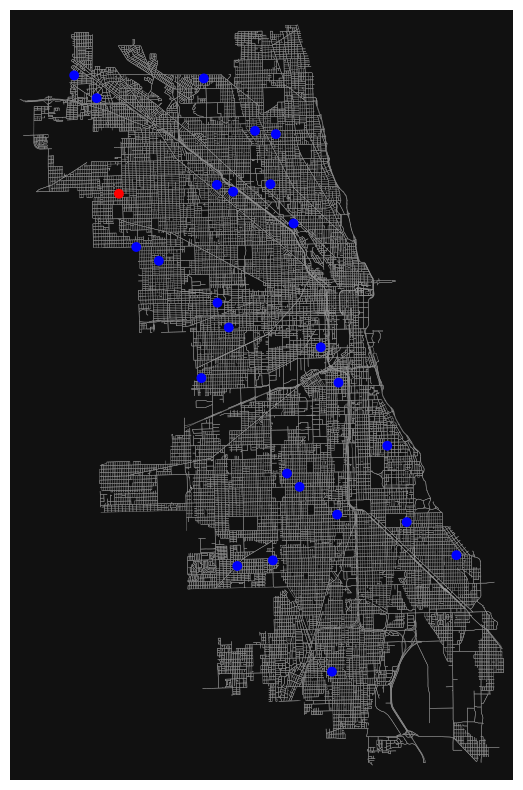

(<Figure size 1000x1000 with 1 Axes>, <Axes: >)

In [ ]:
# visualizamos el deposito y las entregas en el mapa

node_colors = ["red" if n == deposito else "blue" for n in G.nodes]
node_sizes = [50 if n in puntos_elegidos else 0 for n in G.nodes]

ox.plot_graph(G, node_color=node_colors, node_size=node_sizes, edge_linewidth=0.3, figsize=(10, 10))

## 7. Matriz de tiempos

Para cada punto, calculamos con `Dijkstra` el tiempo más corto hasta los demás, usando los pesos asignados al grafo.

También vemos si un par de nodos no tiene camino de uno al otro

In [ ]:
def calcular_matriz_tiempo(G, weight_attr, puntos_elegidos):
    n = len(puntos_elegidos)
    matriz = [[0] * n for _ in range(n)]
    for i, origen in enumerate(puntos_elegidos):
        tiempos_desde_origen = nx.single_source_dijkstra_path_length(G, origen, weight=weight_attr)
        for j, destino in enumerate(puntos_elegidos):
            if i != j:
                matriz[i][j] = tiempos_desde_origen.get(destino, float("inf"))
    return matriz

# creamos lista para las matrices de los distintos escenarios
escenarios_matrices = {}

## 8. Escenario 1: histórico + LightGBM


Cogemos la última hora disponible del dataset, con datos reales de clima, calendario y eventos.

In [ ]:
# elegimos momento historico
momento_demo = con.sql(f"""
    SELECT *
    FROM '{data_clean}/dataset_model.parquet'
    WHERE time_hour = (SELECT MAX(time_hour) FROM '{data_clean}/dataset_model.parquet')
""").df()

# hora
momento_hora = pd.to_datetime(momento_demo["time_hour"].iloc[0])

# informacion que afecta a todo chicago por igual
print(momento_demo[["time_hour", "hora", "dia_semana", "mes", "temperature_2m", "rain", "festivo", "school_holiday"]].drop_duplicates())
print(f"Segmentos con datos de tráfico en este momento: {momento_demo['segment_id'].nunique()}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

            time_hour  hora  dia_semana  mes  temperature_2m  rain  festivo  \
0 2026-04-30 01:00:00     1           4    4            5.85   0.0        0   

   school_holiday  
0               0  
Segmentos con datos de tráfico en este momento: 514


La última hora disponible del dataet es a la 1AM del 30 de abril de 2026. Solo 514 segmentos tienen datos de tráfico en este momento concreto, es normal ya que no todos los segmentos tienen lecturas todas las horas. Para los demás segmentos monitorizados que no tengan datos en este instante, usamos también el modelo de respaldo, ya que no tenemos `speed_lag1` para ellos.

### 8.1. Predicción con modelo principal

Hacemos la predicción con el modelo principal para esos 514 segmentos:

In [ ]:
# prediccion con modelo principal

X_demo_principal = momento_demo.copy()
columnas_cat_principal = ["segment_id", "obra_tipo", "accidente_tipo", "hora", "dia_semana", "mes"]
for col in columnas_cat_principal:
    X_demo_principal[col] = X_demo_principal[col].astype("category")

columnas_modelo_principal = modelo_principal.feature_name()
X_demo_principal = X_demo_principal[columnas_modelo_principal]

# prediccion
momento_demo["pred_speed"] = modelo_principal.predict(X_demo_principal)
print(momento_demo[["segment_id", "avg_speed", "pred_speed"]].head())

   segment_id  avg_speed  pred_speed
0         913       23.0   25.118686
1        1248       24.0   27.219695
2         152       26.0   23.208313
3         105       25.0   27.375566
4         210       23.0   21.961402


Vemos que las predicciones se asemejan bastante a la velocidad media de cada segmento (MAE de 1.85km/h).

### 8.2. Aplicamos eventos a toda la red

A continuación, aplicamos los eventos a todas las aristas de la red (no solo a nuestros segmentos con histórico de tráfico) para este momento histórico, con la misma lógica de radio y ventana temporal que utilizamos en `traffic.ipynb`.

In [ ]:
# 1. festivos, vacaciones escolares y clima

for col in ["school_holiday", "festivo", "temperature_2m", "rain", "snowfall",
            "relative_humidity_2m", "wind_speed_10m", "hora", "dia_semana", "mes", "es_finde"]:
    edges_gdf[col] = momento_demo[col].iloc[0]

# 2. accidentes con ventana segun severidad y radio 400m

edges_accidente = emparejar_evento_red(
    df_crashes, edges_gdf, ["u", "v", "key"], "LATITUDE", "LONGITUDE", "street_norm",
    radio_m=400,
    esta_activo_fn=lambda ev: 0 <= (momento_hora - pd.to_datetime(ev["CRASH_DATE"])).total_seconds() / 3600
                                <= ventana_accidente.get(ev["severity_level"], 1),
    valor_fn=lambda ev: ev["severity_level"], orden=orden_severidad, valor_default="ninguno",
)

edges_gdf["accidente_tipo"] = edges_gdf.apply(lambda r: edges_accidente.get((r["u"], r["v"], r["key"]), "ninguno"), axis=1)

print(f"Aristas con accidente activo: {len(edges_accidente)}")

# 3. obras con radio 400m

edges_obra = emparejar_evento_red(
    df_closures, edges_gdf, ["u", "v", "key"], "LATITUDE", "LONGITUDE", "street_norm",
    radio_m=400,
    esta_activo_fn=lambda ev: pd.to_datetime(ev["APPLICATIONSTARTDATE"]) <= momento_hora <= pd.to_datetime(ev["APPLICATIONENDDATE"]),
    valor_fn=lambda ev: ev.get("STREETCLOSURE", "ninguna"), orden=orden_cierre, valor_default="ninguna",
)

edges_gdf["obra_tipo"] = edges_gdf.apply(lambda r: edges_obra.get((r["u"], r["v"], r["key"]), "ninguna"), axis=1)

print(f"Aristas con obra activa: {len(edges_obra)}")

# 4. partidos con ventana y radio 1500m

edges_partido = emparejar_evento_red(
    df_matches, edges_gdf, ["u", "v", "key"], "latitude", "longitude", None,
    radio_m=1500,
    esta_activo_fn=lambda ev: -3 <= (momento_hora - ev["date"]).total_seconds() / 3600 <= 5,
    valor_fn=lambda ev: 1,
)

edges_gdf["partido"] = edges_gdf.apply(lambda r: edges_partido.get((r["u"], r["v"], r["key"]), 0), axis=1)

print(f"Aristas con partido activo: {len(edges_partido)}")

# 5. conciertos con hora asumida 20:00, ventana ancha y radio 1500m

edges_concierto = emparejar_evento_red(
    df_concerts, edges_gdf, ["u", "v", "key"], "latitude", "longitude", None,
    radio_m=1500,
    esta_activo_fn=lambda ev: -8 <= (momento_hora - (pd.to_datetime(ev["date"]).normalize() + pd.Timedelta(hours=20))).total_seconds() / 3600 <= 6,
    valor_fn=lambda ev: 1,
)

edges_gdf["concierto"] = edges_gdf.apply(lambda r: edges_concierto.get((r["u"], r["v"], r["key"]), 0), axis=1)

print(f"Aristas con concierto activo: {len(edges_concierto)}")

Aristas con accidente activo: 39
Aristas con obra activa: 30696
Aristas con partido activo: 0
Aristas con concierto activo: 1468


### 8.3. Predicción con modelo de respaldo

Hacemos la predicción con el modelo de respaldo para todas las demás aristas.

In [ ]:
# modelo de respaldo
X_demo_respaldo = edges_gdf.copy()
columnas_cat_respaldo = ["obra_tipo", "accidente_tipo", "hora", "dia_semana", "mes", "highway_type"]
for col in columnas_cat_respaldo:
    X_demo_respaldo[col] = X_demo_respaldo[col].astype("category")

columnas_modelo_respaldo = modelo_respaldo.feature_name()
X_demo_respaldo = X_demo_respaldo[columnas_modelo_respaldo]

# prediccion
edges_gdf["pred_speed_respaldo"] = modelo_respaldo.predict(X_demo_respaldo)

### 8.4. Combinamos ambos modelos

Para cada arista, si corresponde a un segmento monitorizado con predicción disponible en ese momento usamos el modelo principal, y sino el de respaldo.

In [ ]:
# combinamos ambos modelos
pred_principal_dict = (
    momento_demo
    .merge(segmentos_monitorizados, on="segment_id")
    .set_index(["osm_u", "osm_v", "osm_key"])["pred_speed"]
    .to_dict()
)

def velocidad_final(row):
    key = (row["u"], row["v"], row["key"])
    return pred_principal_dict.get(key, row["pred_speed_respaldo"])

edges_gdf["pred_speed_final"] = edges_gdf.apply(velocidad_final, axis=1)
edges_gdf["travel_time_hist_lgbm"] = edges_gdf["length"] / (edges_gdf["pred_speed_final"] * 1000 / 3600)

tiempos = edges_gdf.set_index(["u", "v", "key"])["travel_time_hist_lgbm"].to_dict()
nx.set_edge_attributes(G, tiempos, "travel_time_hist_lgbm")

print(edges_gdf["pred_speed_final"].describe())

count    77821.000000
mean        26.002190
std          2.387878
min         16.003488
25%         25.535275
50%         26.087310
75%         26.087310
max         54.480836
Name: pred_speed_final, dtype: float64


In [ ]:
escenarios_matrices["historico_lgbm"] = calcular_matriz_tiempo(G, "travel_time_hist_lgbm", puntos_elegidos)

## 9. Escenario 2: histórico + GCN

Construimos el snapshot para el mismo momento histórico solo para los 1.043 segmentos de la GCN y predecimos. Para las aristas que no pertenecen a esos segmentos, usamos el mismo modelo de respaldo de arriba (los eventos y el contexto de ese momento no cambian entre escenario 1 y 2, solo cambia el modelo que se usa para los segmentos monitorizados).

In [ ]:
momento_demo_gcn_ids = ", ".join(str(int(x)) for x in node_to_idx.keys())

momento_demo_gcn = con.sql(f"""
    SELECT segment_id, avg_speed, speed_lag1, hora, dia_semana, mes, es_finde,
           festivo, school_holiday, temperature_2m, rain, snowfall,
           relative_humidity_2m, wind_speed_10m, partido, concierto, obra_tipo, accidente_tipo
    FROM '{data_clean}/dataset_model.parquet'
    WHERE time_hour = '{momento_hora}'
      AND segment_id IN ({momento_demo_gcn_ids})
""").df()

filas_por_segmento_hist = momento_demo_gcn.set_index("segment_id").to_dict("index")
contexto_hist = momento_demo.iloc[0]

X_hist_gcn = construir_snapshot_gcn(
    filas_por_segmento_hist, contexto_hist["dia_semana"], contexto_hist["hora"], contexto_hist,
    node_to_idx, baseline_dict, len(node_to_idx)
)
pred_hist_gcn = predecir_gcn(X_hist_gcn)

predicciones_gcn_hist = pd.DataFrame({
    "segment_id": [idx_to_node[i] for i in range(len(pred_hist_gcn))],
    "pred_speed_gcn": pred_hist_gcn
})
print(predicciones_gcn_hist.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   segment_id  pred_speed_gcn
0           1       25.217505
1           2       24.781250
2           3       24.814440
3           4       25.915792
4           5       26.345322


In [ ]:
pred_gcn_dict_hist = (
    predicciones_gcn_hist
    .merge(segmentos_monitorizados, on="segment_id")
    .set_index(["osm_u", "osm_v", "osm_key"])["pred_speed_gcn"]
    .to_dict()
)

def velocidad_final_gcn_hist(row):
    key = (row["u"], row["v"], row["key"])
    return pred_gcn_dict_hist.get(key, row["pred_speed_respaldo"])

edges_gdf["pred_speed_final_gcn_hist"] = edges_gdf.apply(velocidad_final_gcn_hist, axis=1)
edges_gdf["travel_time_hist_gcn"] = edges_gdf["length"] / (edges_gdf["pred_speed_final_gcn_hist"] * 1000 / 3600)

tiempos_gcn_hist = edges_gdf.set_index(["u", "v", "key"])["travel_time_hist_gcn"].to_dict()
nx.set_edge_attributes(G, tiempos_gcn_hist, "travel_time_hist_gcn")

print(f"Aristas con predicción de la GCN: {len(pred_gcn_dict_hist)}")

Aristas con predicción de la GCN: 16348


In [ ]:
escenarios_matrices["historico_gcn"] = calcular_matriz_tiempo(G, "travel_time_hist_gcn", puntos_elegidos)

## 10. Datos en vivo

Ahora repetimos el proceso con datos en tiempo real. Sustituimos el momento histórico por las condiciones reales de ahora mismo: tráfico, clima, accidentes, obras, partidos y conciertos desde sus fuentes oficiales, y festivo/vacaciones escolares calculados a partir de nuestro propio calendario y bases de datos.

### 10.1. Tráfico en vivo

Cargamos datos en tiempo real del portal de datos de Chicago.

In [ ]:
# TRAFICO
url_actual = "https://data.cityofchicago.org/resource/n4j6-wkkf.json"
response = requests.get(url_actual, params={"$limit": 2000})
df_trafico_actual = pd.DataFrame(response.json())

df_trafico_actual = df_trafico_actual.rename(columns={
    "segmentid": "segment_id",
    "_direction": "direction",
    "_traffic": "speed_actual",
    "_last_updt": "time_actual"
})

df_trafico_actual["speed_actual"] = pd.to_numeric(df_trafico_actual["speed_actual"])
df_trafico_actual["time_actual"] = pd.to_datetime(df_trafico_actual["time_actual"])
df_trafico_actual["segment_id"] = df_trafico_actual["segment_id"].astype(str)
df_trafico_actual = df_trafico_actual[df_trafico_actual["speed_actual"] != -1]

# segmentos con lectura mas reciente
df_trafico_actual_dedup = (
    df_trafico_actual.sort_values("time_actual", ascending=False).drop_duplicates(subset="segment_id")
)
print(f"Segmentos con lectura disponible: {df_trafico_actual_dedup['segment_id'].nunique()}")
print(f"Lectura más reciente: {df_trafico_actual_dedup['time_actual'].max()}")

Segmentos con lectura disponible: 320
Lectura más reciente: 2026-04-30 01:10:21


Comprobamos la fecha de la lectura más reciente que, según la documentación de Chicago, este feed se actualiza cada 10 minutos. Pero al comprobarlo hemos visto que la lectura más reciente disponible es de abril. Es una limitación de la fuente externa, así que la documentamos y seguimos usando la última lectura disponible de cada segmento como mejor estimación posible.

### 10.2. Clima en vivo

Cargamos datos del clima en tiempo real desde Open-Meteo.

In [ ]:
# CLIMA
lat_chicago, lon_chicago = 41.8781, -87.6298

response_clima = requests.get(
    "https://api.open-meteo.com/v1/forecast",
    params={
        "latitude": lat_chicago,
        "longitude": lon_chicago,
        "current": "temperature_2m,rain,snowfall,relative_humidity_2m,wind_speed_10m",
        "timezone": "America/Chicago"
    }
)
clima_actual = response_clima.json()["current"]
print(clima_actual)

{'time': '2026-08-24T11:30', 'interval': 900, 'temperature_2m': 20.8, 'rain': 0.0, 'snowfall': 0.0, 'relative_humidity_2m': 58, 'wind_speed_10m': 12.5}


### 10.3. Fecha, hora, festivo y vacaciones escolares reales

La hora y el día los calculamos directamente. Los festivo y las vacaciones escolares los buscamos en nuestro calendario.

In [ ]:
# FECHA/HORA/FESTIVOS

ahora_chicago = pd.Timestamp.now(tz="America/Chicago")
ahora_naive = ahora_chicago.tz_localize(None)

hora_actual = ahora_chicago.hour
dia_semana_actual = (ahora_chicago.dayofweek + 1) % 7
mes_actual = ahora_chicago.month
es_finde_actual = 1 if ahora_chicago.dayofweek >= 5 else 0

df_holidays["date"] = pd.to_datetime(df_holidays["date"]).dt.date
fila_hoy = df_holidays[df_holidays["date"] == ahora_chicago.date()]
festivo_actual = int(fila_hoy["festivo"].iloc[0]) if len(fila_hoy) > 0 else 0
school_holiday_actual = int(fila_hoy["school_holiday"].iloc[0]) if len(fila_hoy) > 0 else 0

print(ahora_chicago, hora_actual, dia_semana_actual, mes_actual, es_finde_actual)
print(f"Festivo: {festivo_actual}, vacaciones escolares: {school_holiday_actual}")

2026-08-24 11:35:47.266244-05:00 11 1 8 0
Festivo: 0, vacaciones escolares: 0


### 10.4. Accidentes y obras en vivo

Consultamos directamente los datasets en vivo del portal de Chicago: accidentes de los últimos días y obras activas ahora mismo.

In [ ]:
# ACCIDENTES

url_crashes = "https://data.cityofchicago.org/resource/85ca-t3if.json"
# ponemos ventana de 6 horas (2h de margen), un lim de 500 y cogemos los mas recientes
response_crashes = requests.get(url_crashes, params={
    "$where": f"crash_date > '{(ahora_naive - pd.Timedelta(hours=6)).isoformat()}'",
    "$order": "crash_date DESC",
    "$limit": 500
})
data_crashes = response_crashes.json()

# vemos si hay accidentes
if len(data_crashes) == 0:
    print("No hay accidentes reportados en las últimas 6 horas.")
    df_crashes_actual = pd.DataFrame(columns=["crash_date", "street_name", "latitude", "longitude", "severity_level", "street_norm"])
else:
    df_crashes_actual = pd.DataFrame(data_crashes)
    mapeo_severidad = {
        "NO INDICATION OF INJURY": "sin_heridos",
        "REPORTED, NOT EVIDENT": "leve",
        "NONINCAPACITATING INJURY": "leve",
        "INCAPACITATING INJURY": "grave",
        "FATAL": "fatal",
    }
    # si tenemos algun NaN, lo ocnvertimos en sin_heridos
    df_crashes_actual["severity_level"] = df_crashes_actual["most_severe_injury"].map(mapeo_severidad).fillna("sin_heridos")
    # normalizar nombre calle
    df_crashes_actual["street_norm"] = normalizar_calle(df_crashes_actual["street_name"])
    df_crashes_actual["latitude"] = pd.to_numeric(df_crashes_actual["latitude"])
    df_crashes_actual["longitude"] = pd.to_numeric(df_crashes_actual["longitude"])

    print(df_crashes_actual["severity_level"].value_counts(dropna=False))

No hay accidentes reportados en las últimas 6 horas.


In [ ]:
# CIERRES (OBRAS)

url_closures = "https://data.cityofchicago.org/resource/jdis-5sry.json"
# limite de 10000
response_closures = requests.get(url_closures, params={
    "$where": f"applicationstartdate <= '{ahora_naive.isoformat()}' AND applicationenddate >= '{ahora_naive.isoformat()}'",
    "$limit": 10000
})

data_closures = response_closures.json()

if len(data_closures) == 0:
    print("No hay obras activas ahora mismo.")
    df_closures_actual = pd.DataFrame(columns=["streetname", "latitude", "longitude", "streetclosure", "street_norm"])
else:
    df_closures_actual = pd.DataFrame(data_closures)

    # normalizar nombre calle
    df_closures_actual["street_norm"] = normalizar_calle(df_closures_actual["streetname"])
    df_closures_actual["latitude"] = pd.to_numeric(df_closures_actual["latitude"])
    df_closures_actual["longitude"] = pd.to_numeric(df_closures_actual["longitude"])

    # quitamos sidewalk, afectan a peatones no al tráfico
    cierres_trafico = {"ninguna", "Curblane", "Partial", "Full", "Intermitte"}
    df_closures_actual["streetclosure"] = df_closures_actual["streetclosure"].apply(
        lambda v: v if v in cierres_trafico else "ninguna"
    )

    print(df_closures_actual["streetclosure"].value_counts(dropna=False))

streetclosure
Curblane      3636
ninguna       1402
Full           649
Partial        523
Intermitte       1
Name: count, dtype: int64


### 10.5. Partidos y conciertos en vivo

Para conseguir datos de partidos y conciertos en vivo, hacemos una llamada a `Ticketmaster`, que contiene datos de eventos de todo el mundo.

Los partidos los buscamos combinando nuestro calendario (`df_matches`) con lo que devuelve Ticketmaster ahora mismo, para tener la mejor cobertura posible. Los conciertos solo con Ticketmaster, ya que setlist.fm solo tiene conciertos pasados (la gente sube el setlist después de ir) y no nos sirve para saber si hay uno ocurriendo ahora.

In [ ]:
def obtener_eventos_ticketmaster(classification_name, dias_ventana=2):
    """ Esta función busca eventos en Ticketmaster cerca de Chicago, en una
    ventana de tiempo."""
    inicio = (ahora_chicago - pd.Timedelta(days=dias_ventana)).tz_convert("UTC")
    fin = (ahora_chicago + pd.Timedelta(days=dias_ventana)).tz_convert("UTC")
    try:
        response = requests.get(
            "https://app.ticketmaster.com/discovery/v2/events.json",
            params={
                "apikey": api_ticketmaster,
                "latlong": f"{lat_chicago},{lon_chicago}",
                "radius": "30",
                "unit": "miles",
                "classificationName": classification_name,
                "startDateTime": inicio.strftime("%Y-%m-%dT%H:%M:%SZ"),
                "endDateTime": fin.strftime("%Y-%m-%dT%H:%M:%SZ"),
                "size": 200,
            }
        )
        data = response.json()
    except Exception as e:
        print(f"Error en Ticketmaster ({classification_name}): {e}")
        return pd.DataFrame(columns=["name", "date", "latitude", "longitude"])

    eventos = []
    for ev in data.get("_embedded", {}).get("events", []):
        try:
            fecha_utc = pd.to_datetime(ev["dates"]["start"]["dateTime"])
            fecha_chicago = fecha_utc.tz_convert("America/Chicago").tz_localize(None)
            venue = ev["_embedded"]["venues"][0]
            eventos.append({
                "name": ev["name"], "date": fecha_chicago,
                "latitude": float(venue["location"]["latitude"]),
                "longitude": float(venue["location"]["longitude"])
            })
        except (KeyError, IndexError):
            continue
    return pd.DataFrame(eventos, columns=["name", "date", "latitude", "longitude"])

df_concerts_tm = obtener_eventos_ticketmaster("Music")
df_matches_tm = obtener_eventos_ticketmaster("Sports")

df_matches_combinado = pd.concat(
    [df_matches[["date", "latitude", "longitude"]], df_matches_tm[["date", "latitude", "longitude"]]],
    ignore_index=True
)

print(f"Conciertos encontrados cerca de ahora: {len(df_concerts_tm)}")
print(f"Partidos encontrados cerca de ahora: {len(df_matches_tm)}")

Conciertos encontrados cerca de ahora: 11
Partidos encontrados cerca de ahora: 5


### 10.6. Aplicamos los eventos a nuestros segmentos monitorizados

Utilizamos la misma función que usamos para la red completa en el escenario histórico, pero ahora contra `dim_segmentos` y con el momento actual.

In [ ]:
dim_segmentos = pd.read_parquet(f"{data_clean}/dim_segmentos.parquet")
dim_segmentos["street_norm"] = normalizar_calle(dim_segmentos["street"])
dim_segmentos["mid_lat"] = (dim_segmentos["start_latitude"] + dim_segmentos["end_latitude"]) / 2
dim_segmentos["mid_lon"] = (dim_segmentos["start_longitude"] + dim_segmentos["end_longitude"]) / 2

# accidentes
segmentos_accidente_vivo = emparejar_evento_red(
    df_crashes_actual, dim_segmentos, ["segment_id"], "latitude", "longitude", "street_norm",
    radio_m=400,
    esta_activo_fn=lambda ev: 0 <= (ahora_naive - pd.to_datetime(ev["crash_date"])).total_seconds() / 3600
                                <= ventana_accidente.get(ev["severity_level"], 1),
    valor_fn=lambda ev: ev["severity_level"], orden=orden_severidad, valor_default="ninguno",
)

# cierres/obras
segmentos_obra_vivo = emparejar_evento_red(
    df_closures_actual, dim_segmentos, ["segment_id"], "latitude", "longitude", "street_norm",
    radio_m=400, esta_activo_fn=lambda ev: True,
    valor_fn=lambda ev: ev.get("streetclosure", "ninguna"), orden=orden_cierre, valor_default="ninguna",
)

# partidos
segmentos_partido_vivo = emparejar_evento_red(
    df_matches_combinado, dim_segmentos, ["segment_id"], "latitude", "longitude", None,
    radio_m=1500,
    esta_activo_fn=lambda ev: -3 <= (ahora_naive - ev["date"]).total_seconds() / 3600 <= 5,
    valor_fn=lambda ev: 1,
)

# conciertos
segmentos_concierto_vivo = emparejar_evento_red(
    df_concerts_tm, dim_segmentos, ["segment_id"], "latitude", "longitude", None,
    radio_m=1500,
    esta_activo_fn=lambda ev: -3 <= (ahora_naive - ev["date"]).total_seconds() / 3600 <= 5,
    valor_fn=lambda ev: 1,
)

print(f"Segmentos con accidente activo: {len(segmentos_accidente_vivo)}")
print(f"Segmentos con obra activa: {len(segmentos_obra_vivo)}")
print(f"Segmentos con partido activo: {len(segmentos_partido_vivo)}")
print(f"Segmentos con concierto activo: {len(segmentos_concierto_vivo)}")

Segmentos con accidente activo: 0
Segmentos con obra activa: 366
Segmentos con partido activo: 0
Segmentos con concierto activo: 0


## 11. Escenario 3: en vivo + LightGBM

Primero construimos el momento actual para nuestros segmentos.

In [ ]:
momento_vivo = dim_segmentos[["segment_id"]].copy()
momento_vivo["segment_id_str"] = momento_vivo["segment_id"].astype(str)

momento_vivo = momento_vivo.merge(
    df_trafico_actual_dedup[["segment_id", "speed_actual"]].rename(columns={"segment_id": "segment_id_str"}),
    on="segment_id_str", how="left"
).rename(columns={"speed_actual": "speed_lag1"}).drop(columns="segment_id_str")

momento_vivo["school_holiday"] = school_holiday_actual
momento_vivo["festivo"] = festivo_actual
momento_vivo["temperature_2m"] = clima_actual["temperature_2m"]
momento_vivo["rain"] = clima_actual["rain"]
momento_vivo["snowfall"] = clima_actual["snowfall"]
momento_vivo["relative_humidity_2m"] = clima_actual["relative_humidity_2m"]
momento_vivo["wind_speed_10m"] = clima_actual["wind_speed_10m"]
momento_vivo["hora"] = hora_actual
momento_vivo["dia_semana"] = dia_semana_actual
momento_vivo["mes"] = mes_actual
momento_vivo["es_finde"] = es_finde_actual

momento_vivo["accidente_tipo"] = momento_vivo["segment_id"].map(segmentos_accidente_vivo).fillna("ninguno")
momento_vivo["obra_tipo"] = momento_vivo["segment_id"].map(segmentos_obra_vivo).fillna("ninguna")
momento_vivo["partido"] = momento_vivo["segment_id"].map(segmentos_partido_vivo).fillna(0).astype(int)
momento_vivo["concierto"] = momento_vivo["segment_id"].map(segmentos_concierto_vivo).fillna(0).astype(int)

segmentos_con_dato = momento_vivo[momento_vivo["speed_lag1"].notna()].copy()
segmentos_sin_dato = momento_vivo[momento_vivo["speed_lag1"].isna()].copy()

print(f"Segmentos con dato de tráfico (modelo principal): {len(segmentos_con_dato)}")
print(f"Segmentos sin dato de tráfico (modelo de respaldo): {len(segmentos_sin_dato)}")

Segmentos con dato de tráfico (modelo principal): 320
Segmentos sin dato de tráfico (modelo de respaldo): 726


In [ ]:
# modelo principal

X_vivo_principal = segmentos_con_dato.copy()

columnas_cat_principal = ["segment_id", "obra_tipo", "accidente_tipo", "hora", "dia_semana", "mes"]
for col in columnas_cat_principal:
    X_vivo_principal[col] = X_vivo_principal[col].astype("category")

columnas_modelo_principal = modelo_principal.feature_name()
X_vivo_principal = X_vivo_principal[columnas_modelo_principal]

segmentos_con_dato["pred_speed"] = modelo_principal.predict(X_vivo_principal)

# actualizamos el mapeo segment_id -> predicción
pred_principal_dict_vivo = (
    segmentos_con_dato
    .merge(segmentos_monitorizados, on="segment_id")
    .set_index(["osm_u", "osm_v", "osm_key"])["pred_speed"]
    .to_dict()
)

print(f"Aristas con predicción en vivo del modelo principal: {len(pred_principal_dict_vivo)}")
print(segmentos_con_dato[["segment_id", "speed_lag1", "pred_speed"]].head(5))

Aristas con predicción en vivo del modelo principal: 5660
   segment_id  speed_lag1  pred_speed
3         137        30.0   27.770748
4         139        27.0   26.894810
5         135        27.0   25.502270
6         150        31.0   26.665859
9         154        21.0   21.742290


Aplicamos los eventos a toda la red, en vivo (para el modelo de respaldo). Igual que hicimos en el escenario histórico, pero con los eventos actuales.

In [ ]:
edges_gdf_vivo = edges_gdf[["u", "v", "key", "length", "street_norm", "mid_lat", "mid_lon", "highway_type"]].copy()

for col, val in {
    "school_holiday": school_holiday_actual, "festivo": festivo_actual,
    "temperature_2m": clima_actual["temperature_2m"], "rain": clima_actual["rain"],
    "snowfall": clima_actual["snowfall"], "relative_humidity_2m": clima_actual["relative_humidity_2m"],
    "wind_speed_10m": clima_actual["wind_speed_10m"],
    "hora": hora_actual, "dia_semana": dia_semana_actual, "mes": mes_actual, "es_finde": es_finde_actual,
}.items():
    edges_gdf_vivo[col] = val

edges_accidente_vivo = emparejar_evento_red(
    df_crashes_actual, edges_gdf_vivo, ["u", "v", "key"], "latitude", "longitude", "street_norm",
    radio_m=400,
    esta_activo_fn=lambda ev: 0 <= (ahora_naive - pd.to_datetime(ev["crash_date"])).total_seconds() / 3600
                                <= ventana_accidente.get(ev["severity_level"], 1),
    valor_fn=lambda ev: ev["severity_level"], orden=orden_severidad, valor_default="ninguno",
)
edges_obra_vivo = emparejar_evento_red(
    df_closures_actual, edges_gdf_vivo, ["u", "v", "key"], "latitude", "longitude", "street_norm",
    radio_m=400, esta_activo_fn=lambda ev: True,
    valor_fn=lambda ev: ev.get("streetclosure", "ninguna"), orden=orden_cierre, valor_default="ninguna",
)
edges_partido_vivo = emparejar_evento_red(
    df_matches_combinado, edges_gdf_vivo, ["u", "v", "key"], "latitude", "longitude", None,
    radio_m=1500, esta_activo_fn=lambda ev: -3 <= (ahora_naive - ev["date"]).total_seconds() / 3600 <= 5,
    valor_fn=lambda ev: 1,
)
edges_concierto_vivo = emparejar_evento_red(
    df_concerts_tm, edges_gdf_vivo, ["u", "v", "key"], "latitude", "longitude", None,
    radio_m=1500, esta_activo_fn=lambda ev: -3 <= (ahora_naive - ev["date"]).total_seconds() / 3600 <= 5,
    valor_fn=lambda ev: 1,
)

edges_gdf_vivo["accidente_tipo"] = edges_gdf_vivo.apply(lambda r: edges_accidente_vivo.get((r["u"], r["v"], r["key"]), "ninguno"), axis=1)
edges_gdf_vivo["obra_tipo"] = edges_gdf_vivo.apply(lambda r: edges_obra_vivo.get((r["u"], r["v"], r["key"]), "ninguna"), axis=1)
edges_gdf_vivo["partido"] = edges_gdf_vivo.apply(lambda r: edges_partido_vivo.get((r["u"], r["v"], r["key"]), 0), axis=1)
edges_gdf_vivo["concierto"] = edges_gdf_vivo.apply(lambda r: edges_concierto_vivo.get((r["u"], r["v"], r["key"]), 0), axis=1)

print(f"Aristas con accidente activo: {len(edges_accidente_vivo)}")
print(f"Aristas con obra activa: {len(edges_obra_vivo)}")
print(f"Aristas con partido activo: {len(edges_partido_vivo)}")
print(f"Aristas con concierto activo: {len(edges_concierto_vivo)}")

Aristas con accidente activo: 0
Aristas con obra activa: 25421
Aristas con partido activo: 0
Aristas con concierto activo: 0


In [ ]:
X_vivo_respaldo = edges_gdf_vivo.copy()
columnas_cat_respaldo = ["obra_tipo", "accidente_tipo", "hora", "dia_semana", "mes", "highway_type"]
for col in columnas_cat_respaldo:
    X_vivo_respaldo[col] = X_vivo_respaldo[col].astype("category")

columnas_modelo_respaldo = modelo_respaldo.feature_name()
X_vivo_respaldo = X_vivo_respaldo[columnas_modelo_respaldo]

edges_gdf_vivo["pred_speed_respaldo"] = modelo_respaldo.predict(X_vivo_respaldo)

In [ ]:
# asignar pesos

def velocidad_final_vivo(row):
    key = (row["u"], row["v"], row["key"])
    return pred_principal_dict_vivo.get(key, row["pred_speed_respaldo"])

edges_gdf_vivo["pred_speed_final"] = edges_gdf_vivo.apply(velocidad_final_vivo, axis=1)
edges_gdf_vivo["travel_time_vivo_lgbm"] = edges_gdf_vivo["length"] / (edges_gdf_vivo["pred_speed_final"] * 1000 / 3600)

tiempos_vivo = edges_gdf_vivo.set_index(["u", "v", "key"])["travel_time_vivo_lgbm"].to_dict()
nx.set_edge_attributes(G, tiempos_vivo, "travel_time_vivo_lgbm")

print(edges_gdf_vivo["pred_speed_final"].describe())

count    77821.000000
mean        24.715374
std          2.622505
min         12.361787
25%         23.918632
50%         24.739775
75%         24.739775
max         54.900993
Name: pred_speed_final, dtype: float64


In [ ]:
escenarios_matrices["vivo_lgbm"] = calcular_matriz_tiempo(G, "travel_time_vivo_lgbm", puntos_elegidos)

## 12. Escenario 4: en vivo + GCN

Construimos el snapshot en vivo para los 1.043 segmentos de la GCN, reutilizando los eventos que ya calculamos para el escenario 3 (`segmentos_accidente_vivo`, etc.) y el `speed_lag1` de `df_trafico_actual_dedup`.

In [ ]:
filas_gcn_vivo = {}
for seg_id in node_to_idx.keys():
    fila_trafico = df_trafico_actual_dedup[df_trafico_actual_dedup["segment_id"] == str(seg_id)]
    speed_lag1 = fila_trafico["speed_actual"].iloc[0] if len(fila_trafico) > 0 else np.nan

    filas_gcn_vivo[seg_id] = {
        "speed_lag1": speed_lag1,
        "hora": hora_actual, "dia_semana": dia_semana_actual, "mes": mes_actual, "es_finde": es_finde_actual,
        "festivo": festivo_actual, "school_holiday": school_holiday_actual,
        "temperature_2m": clima_actual["temperature_2m"], "rain": clima_actual["rain"],
        "snowfall": clima_actual["snowfall"], "relative_humidity_2m": clima_actual["relative_humidity_2m"],
        "wind_speed_10m": clima_actual["wind_speed_10m"],
        "partido": segmentos_partido_vivo.get(seg_id, 0),
        "concierto": segmentos_concierto_vivo.get(seg_id, 0),
        "obra_tipo": segmentos_obra_vivo.get(seg_id, "ninguna"),
        "accidente_tipo": segmentos_accidente_vivo.get(seg_id, "ninguno"),
    }

contexto_vivo = {
    "mes": mes_actual, "es_finde": es_finde_actual, "festivo": festivo_actual,
    "school_holiday": school_holiday_actual, "temperature_2m": clima_actual["temperature_2m"],
    "rain": clima_actual["rain"], "snowfall": clima_actual["snowfall"],
    "relative_humidity_2m": clima_actual["relative_humidity_2m"], "wind_speed_10m": clima_actual["wind_speed_10m"],
}

X_vivo_gcn = construir_snapshot_gcn(
    filas_gcn_vivo, dia_semana_actual, hora_actual, contexto_vivo,
    node_to_idx, baseline_dict, len(node_to_idx)
)
pred_vivo_gcn = predecir_gcn(X_vivo_gcn)

predicciones_gcn_vivo = pd.DataFrame({
    "segment_id": [idx_to_node[i] for i in range(len(pred_vivo_gcn))],
    "pred_speed_gcn": pred_vivo_gcn
})
print(predicciones_gcn_vivo.head())

   segment_id  pred_speed_gcn
0           1       24.484295
1           2       24.075666
2           3       24.244694
3           4       25.220079
4           5       25.096468


In [ ]:
pred_gcn_dict_vivo = (
    predicciones_gcn_vivo
    .merge(segmentos_monitorizados, on="segment_id")
    .set_index(["osm_u", "osm_v", "osm_key"])["pred_speed_gcn"]
    .to_dict()
)

def velocidad_final_gcn_vivo(row):
    key = (row["u"], row["v"], row["key"])
    return pred_gcn_dict_vivo.get(key, row["pred_speed_respaldo"])

edges_gdf_vivo["pred_speed_final_gcn"] = edges_gdf_vivo.apply(velocidad_final_gcn_vivo, axis=1)
edges_gdf_vivo["travel_time_vivo_gcn"] = edges_gdf_vivo["length"] / (edges_gdf_vivo["pred_speed_final_gcn"] * 1000 / 3600)

tiempos_gcn_vivo = edges_gdf_vivo.set_index(["u", "v", "key"])["travel_time_vivo_gcn"].to_dict()
nx.set_edge_attributes(G, tiempos_gcn_vivo, "travel_time_vivo_gcn")

print(f"Aristas con predicción de la GCN (en vivo): {len(pred_gcn_dict_vivo)}")

Aristas con predicción de la GCN (en vivo): 16348


In [ ]:
escenarios_matrices["vivo_gcn"] = calcular_matriz_tiempo(G, "travel_time_vivo_gcn", puntos_elegidos)

## 13. Guardamos datos

Guardamos las 4 matrices de los escenarios junto con el depósito, las entregas y el número de vehículos. Para así poder cargarlos en `ortools.ipynb` y `algoritmo_genetico.ipynb` y resolver el problema.

In [ ]:
paquete_escenarios = {
    "puntos_elegidos": puntos_elegidos,
    "deposito": deposito,
    "entregas": entregas,
    "n_vehiculos": n_vehiculos,
    "max_entregas_por_vehiculo": max_entregas_por_vehiculo,
    "matrices": escenarios_matrices,
}

with open(f"{data_clean}/escenarios_vrp.pkl", "wb") as f:
    pickle.dump(paquete_escenarios, f)

print("Escenarios guardados:", list(escenarios_matrices.keys()))
for nombre, matriz in escenarios_matrices.items():
    matriz_np = np.array(matriz)
    print(f"  {nombre}: tiempo medio entre puntos = {matriz_np[matriz_np != np.inf].mean()/60:.1f} min")

Escenarios guardados: ['historico_lgbm', 'historico_gcn', 'vivo_lgbm', 'vivo_gcn']
  historico_lgbm: tiempo medio entre puntos = 32.1 min
  historico_gcn: tiempo medio entre puntos = 32.3 min
  vivo_lgbm: tiempo medio entre puntos = 31.9 min
  vivo_gcn: tiempo medio entre puntos = 33.6 min


También guardamos el grafo `G` con los 4 atributos de tiempo de viaje (`travel_time_hist_lgbm`, `travel_time_hist_gcn`, `travel_time_vivo_lgbm`, `travel_time_vivo_gcn`) que usaremos para dibujar las rutas sobre el mapa siguiendo las calles reales.

In [ ]:
ox.save_graphml(G, filepath=f"{data_clean}/chicago_graph_4_escenarios.graphml")


## 14. Comparativa final

Después de haber creado y ejecutado `ortools.ipynb` y `algoritmo_genetico.ipynb`, cargamos aquí los resultados que conseguimos en esos dos notebooks, y los comparamos todos juntos.

In [ ]:
with open(f"{data_clean}/resultados_ortools.pkl", "rb") as f:
    resultados_ortools = pickle.load(f)

with open(f"{data_clean}/resultados_genetico.pkl", "rb") as f:
    resultados_genetico = pickle.load(f)

filas_comparativa = []
for escenario in escenarios_matrices.keys():
    for metodo, resultados in [("OR-Tools", resultados_ortools), ("Genético", resultados_genetico)]:
        r = resultados[escenario]
        filas_comparativa.append({
            "escenario": escenario,
            "metodo": metodo,
            "vehiculos": r["n_vehiculos_usados"],
            "tiempo_total_min": round(r["tiempo_total"] / 60, 1),
            "makespan_min": round(r["makespan"] / 60, 1),
        })

comparativa = pd.DataFrame(filas_comparativa)
print(comparativa.to_string(index=False))

     escenario   metodo  vehiculos  tiempo_total_min  makespan_min
historico_lgbm OR-Tools          4             548.3         141.9
historico_lgbm Genético          4             626.2         158.6
 historico_gcn OR-Tools          4             561.1         143.4
 historico_gcn Genético          4             605.0         154.6
     vivo_lgbm OR-Tools          4             548.9         139.1
     vivo_lgbm Genético          4             596.2         154.5
      vivo_gcn OR-Tools          4             599.8         151.7
      vivo_gcn Genético          4             649.2         163.5


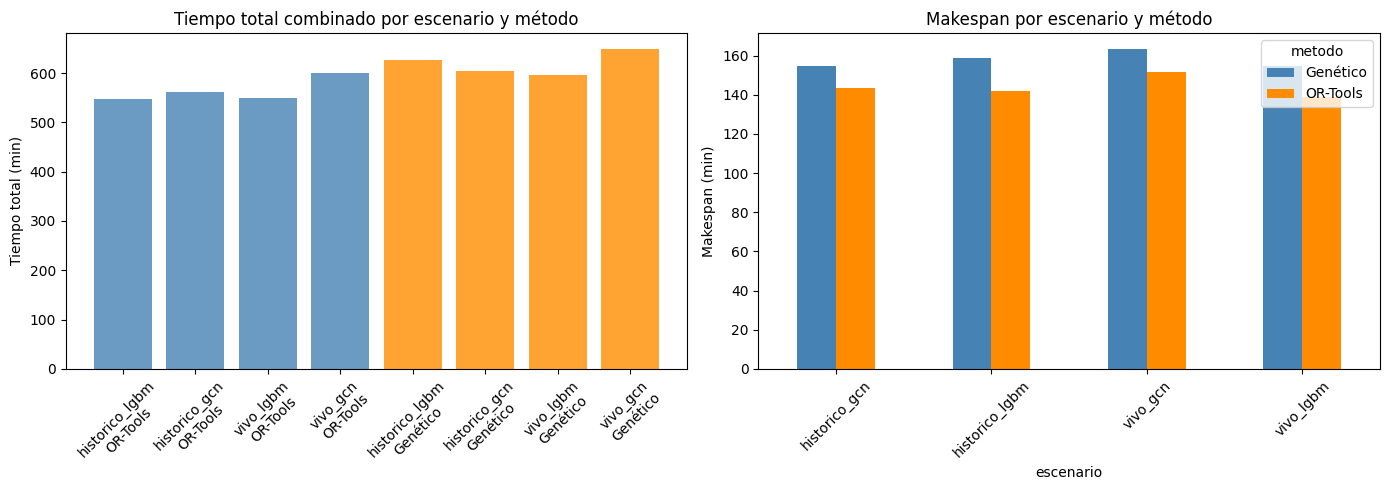

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for metodo, color in [("OR-Tools", "steelblue"), ("Genético", "darkorange")]:
    subset = comparativa[comparativa["metodo"] == metodo]
    axes[0].bar(
        [f"{e}\n{metodo}" for e in subset["escenario"]], subset["tiempo_total_min"],
        color=color, alpha=0.8, label=metodo
    )

axes[0].set_ylabel("Tiempo total (min)")
axes[0].set_title("Tiempo total combinado por escenario y método")
axes[0].tick_params(axis="x", rotation=45)

pivote_makespan = comparativa.pivot(index="escenario", columns="metodo", values="makespan_min")
pivote_makespan.plot(kind="bar", ax=axes[1], color=["steelblue", "darkorange"])
axes[1].set_ylabel("Makespan (min)")
axes[1].set_title("Makespan por escenario y método")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

Con esto ya tenemos la comparación completa: 4 escenarios (histórico/en vivo × LightGBM/GCN) resueltos con 2 métodos distintos (OR-Tools y algoritmo genético). Conseguimos en total 8 soluciones sobre el mismo depósito y las mismas entregas.

En los 4 escenarios, OR-Tools encuentra mejores soluciones que el algoritmo genético, tanto en el makespan  (10-14 minutos de diferencia) como en el tiempo total combinado (50-80 minutos de diferencia).

Es un resultado esperable, ya que OR-Tools usa Guided Local Search, una metaheurística muy refinada y optimizada específicamente para problemas de rutas, mientras que el genético es una implementación propia con operadores estándar.

El escenario `vivo_gcn` es el que peor resultado nos da en ambos métodos (163.5 min de makespan con el genético y 151.7 min con OR-Tools), mientras que `vivo_lgbm` y `historico_lgbm` son los más rápidos con OR-Tools.